# Chi-Square Distribution

The **Chi-square (χ²) distribution** is the sum of squares of ν independent standard normal variables. It is right-skewed for small ν but approaches Normal as ν increases. It underlies **goodness-of-fit tests**, **independence tests** in contingency tables, and **confidence intervals for variance**.

| Property | Value |
|---|---|
| **Parameter** | ν (degrees of freedom, ν > 0) |
| **Support** | [0, +∞) |
| **Definition** | χ²(ν) = Z₁² + Z₂² + … + Zᵥ² where Zᵢ ~ N(0,1) |
| **Mean** | ν |
| **Variance** | 2ν |
| **Mode** | max(ν−2, 0) |
| **Skewness** | √(8/ν) — decreases as ν↑ |
| **Relationship** | χ²(ν) = Gamma(ν/2, 2); χ²(2) = Exponential(2) |
| **Primary use** | Goodness-of-fit, contingency table independence, CI for σ² |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

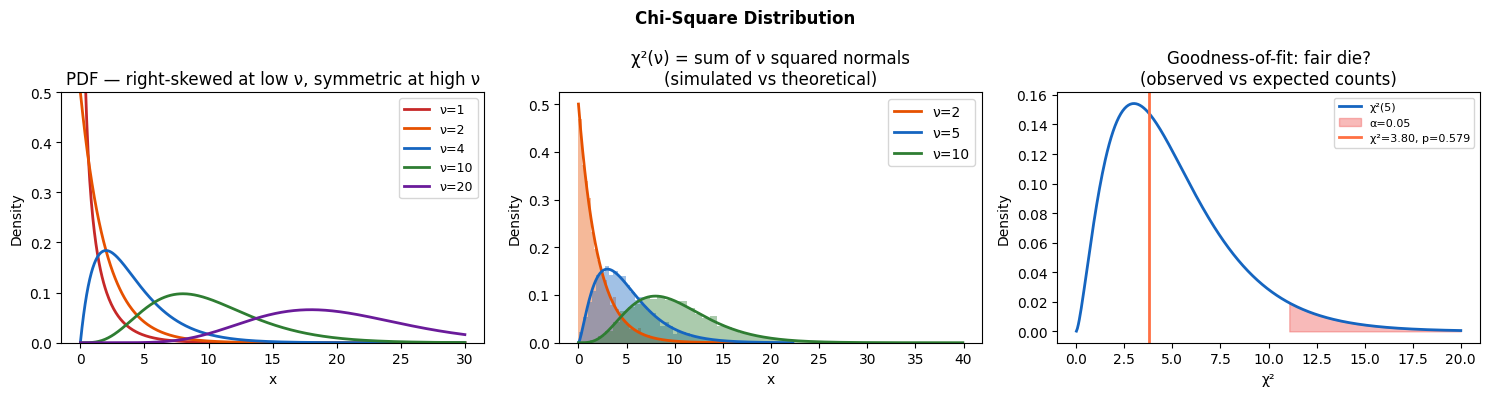

Dice GOF test: χ²=3.800, df=5, p=0.5786
Observed: [18 22 15 25 17 23], Expected: [20 20 20 20 20 20]


In [2]:
x = np.linspace(0.01, 30, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chi-Square Distribution', fontsize=12, fontweight='bold')

# PDF — varying df
for df, color, label in [(1,  '#C62828', 'ν=1'),
                          (2,  '#E65100', 'ν=2'),
                          (4,  '#1565C0', 'ν=4'),
                          (10, '#2E7D32', 'ν=10'),
                          (20, '#6A1B9A', 'ν=20')]:
    axes[0].plot(x, stats.chi2(df).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed at low ν, symmetric at high ν')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=9)

# χ² as sum of squared normals
np.random.seed(42)
n_sim = 5000
for df, color, label in [(2, '#E65100', 'ν=2'), (5, '#1565C0', 'ν=5'), (10, '#2E7D32', 'ν=10')]:
    simulated = np.sum(np.random.normal(0, 1, (n_sim, df))**2, axis=1)
    axes[1].hist(simulated, bins=50, density=True, alpha=0.4, color=color)
    x_plot = np.linspace(0, simulated.max(), 300)
    axes[1].plot(x_plot, stats.chi2(df).pdf(x_plot), color=color, linewidth=2, label=label)
axes[1].set_title('χ²(ν) = sum of ν squared normals\n(simulated vs theoretical)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Goodness-of-fit test (dice fairness)
observed = np.array([18, 22, 15, 25, 17, 23])  # 120 rolls
expected = np.full(6, 20.0)  # fair die: 20 per face
chi2_stat, p_val = stats.chisquare(observed, expected)
df_gof = len(observed) - 1
x_chi = np.linspace(0.01, 20, 400)
axes[2].plot(x_chi, stats.chi2(df_gof).pdf(x_chi),
             color='#1565C0', linewidth=2, label=f'χ²({df_gof})')
x_crit = stats.chi2(df_gof).ppf(0.95)
axes[2].fill_between(x_chi, stats.chi2(df_gof).pdf(x_chi),
                     where=(x_chi >= x_crit),
                     color='#EF5350', alpha=0.4, label=f'α=0.05')
axes[2].axvline(chi2_stat, color='#FF7043', linewidth=2,
                label=f'χ²={chi2_stat:.2f}, p={p_val:.3f}')
axes[2].set_title('Goodness-of-fit: fair die?\n(observed vs expected counts)')
axes[2].set_xlabel('χ²'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Dice GOF test: χ²={chi2_stat:.3f}, df={df_gof}, p={p_val:.4f}")
print(f"Observed: {observed}, Expected: {expected.astype(int)}")

## Key Takeaways

| | |
|---|---|
| **Definition** | χ²(ν) = Z₁² + … + Zᵥ² — sum of squared standard normals |
| **Shape** | Strongly right-skewed at low ν; approaches Normal as ν → ∞ |
| **Goodness-of-fit** | χ² = Σ (Oᵢ−Eᵢ)²/Eᵢ; df = categories − 1 − estimated params |
| **Independence test** | Contingency table: df = (rows−1)(cols−1) |
| **Variance CI** | ((n−1)s²/χ²(α/2), (n−1)s²/χ²(1−α/2)) — CI for population σ² |
| **Additive** | χ²(ν₁) + χ²(ν₂) = χ²(ν₁+ν₂) — degrees of freedom add |
| **Relationship** | Special case of Gamma: χ²(ν) = Gamma(shape=ν/2, scale=2) |